# Logistic Regression Classification Analysis for Heart Disease Prediction
**Machine Learning Assignment — Member 1**  
**Algorithm: Logistic Regression (Binary Classification)**

---

In [9]:
# Core libraries for data handling and visualization
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Utilities for splitting, tuning, and evaluating the model
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Data Loading and Parsing
Load the heart dataset, inspect dimensions, and define a binary disease target.

In [10]:
# Load the heart dataset from the project data folder
data_path = Path("../data/heart_disease_uci.csv")
df = pd.read_csv(data_path)

# Convert the original diagnosis into a binary target label
y = (df["num"] > 0).astype(int)
X = df.drop(columns=["num", "id", "dataset"])

print("Dataset shape:", df.shape)
print("Feature matrix shape:", X.shape)
print("Class distribution:\n", y.value_counts())

Dataset shape: (920, 16)
Feature matrix shape: (920, 13)
Class distribution:
 num
1    509
0    411
Name: count, dtype: int64


## Data Cleaning and Preprocessing
Split the data with stratification and build preprocessing pipelines for numeric and categorical features.

In [11]:
# Split the data into training and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Separate numeric and categorical columns so each can be processed appropriately
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Build preprocessing pipelines for numeric and categorical data
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Combine preprocessing steps into one transformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features),
])

## Model Training and Baseline Evaluation
Train a baseline logistic regression model and evaluate key classification metrics.

In [12]:
# Define a reusable evaluation helper for predictions and probabilities
def evaluate_model(model, X_eval, y_eval, title):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    metrics = {
        "acc": accuracy_score(y_eval, y_pred),
        "prec": precision_score(y_eval, y_pred, zero_division=0),
        "rec": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "auc": roc_auc_score(y_eval, y_prob),
    }

    print(title)
    print(f"Accuracy : {metrics['acc']:.4f}")
    print(f"Precision: {metrics['prec']:.4f}")
    print(f"Recall   : {metrics['rec']:.4f}")
    print(f"F1-score : {metrics['f1']:.4f}")
    print(f"ROC-AUC  : {metrics['auc']:.4f}")

    print("\nConfusion Matrix:\n", confusion_matrix(y_eval, y_pred))
    print("\nClassification Report:\n", classification_report(y_eval, y_pred, zero_division=0))

    return y_pred, y_prob, metrics

# Train the baseline logistic regression pipeline
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])

baseline_model.fit(X_train, y_train)
base_pred, base_prob, baseline_metrics = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    "Baseline Logistic Regression Results",
)

Baseline Logistic Regression Results
Accuracy : 0.8424
Precision: 0.8411
Recall   : 0.8824
F1-score : 0.8612
ROC-AUC  : 0.9035

Confusion Matrix:
 [[65 17]
 [12 90]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



## Hyperparameter Tuning
Use GridSearchCV with stratified folds to optimize F1 while keeping robust ROC-AUC performance.

In [13]:
# Search for the best regularization strength and solver configuration
param_grid = {
    "model__solver": ["liblinear", "lbfgs"],
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__class_weight": [None, "balanced"],
}

# Use stratified cross-validation so class balance stays consistent across folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise",
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV F1:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'model__C': 1, 'model__class_weight': None, 'model__solver': 'liblinear'}
Best CV F1: 0.8324


In [14]:
# Evaluate the tuned logistic regression model on the holdout test set
best_pred, best_prob, tuned_metrics = evaluate_model(
    best_model,
    X_test,
    y_test,
    "Tuned Logistic Regression Results",
)

# Compare baseline and tuned metrics side by side
summary_df = pd.DataFrame([
    {"model": "baseline", **baseline_metrics},
    {"model": "tuned", **tuned_metrics},
]).set_index("model")

print("\nLogistic Regression Summary Table:")
print(summary_df.round(4))

Tuned Logistic Regression Results
Accuracy : 0.8424
Precision: 0.8411
Recall   : 0.8824
F1-score : 0.8612
ROC-AUC  : 0.9035

Confusion Matrix:
 [[65 17]
 [12 90]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


Logistic Regression Summary Table:
             acc    prec     rec      f1     auc
model                                           
baseline  0.8424  0.8411  0.8824  0.8612  0.9035
tuned     0.8424  0.8411  0.8824  0.8612  0.9035


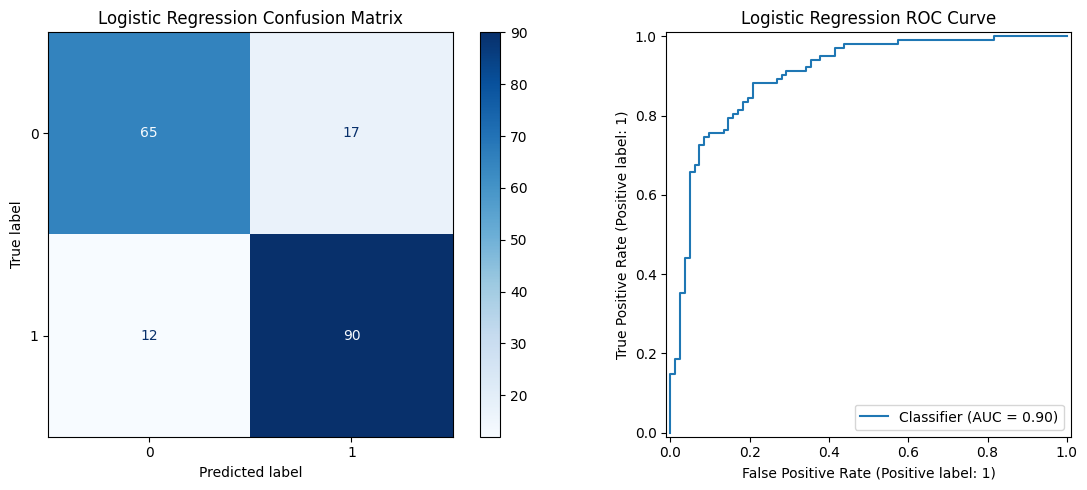


Threshold Tuning Table:
   threshold  precision  recall      f1
0        0.3     0.7619  0.9412  0.8421
1        0.4     0.8000  0.9020  0.8479
2        0.5     0.8411  0.8824  0.8612
3        0.6     0.8485  0.8235  0.8358
4        0.7     0.8681  0.7745  0.8187


In [15]:
# Plot the confusion matrix and ROC curve for the tuned model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=axes[0], cmap="Blues")
axes[0].set_title("Logistic Regression Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, best_prob, ax=axes[1])
axes[1].set_title("Logistic Regression ROC Curve")
plt.tight_layout()
plt.show()

# Check how the decision threshold changes precision and recall
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_metrics = []
for t in thresholds:
    t_pred = (best_prob >= t).astype(int)
    threshold_metrics.append({
        "threshold": t,
        "precision": precision_score(y_test, t_pred, zero_division=0),
        "recall": recall_score(y_test, t_pred, zero_division=0),
        "f1": f1_score(y_test, t_pred, zero_division=0),
    })

print("\nThreshold Tuning Table:")
print(pd.DataFrame(threshold_metrics).round(4))

## Patient-Level Prediction Example
Run inference for one patient sample and interpret the predicted disease probability.

In [16]:
# Enter patient details manually (edit values as needed)
sample_patient = pd.DataFrame([{
    "age": 20,
    "sex": "Male",
    "cp": "asymptomatic",
    "trestbps": 140,
    "chol": 129,
    "fbs": "FALSE",
    "restecg": "normal",
    "thalch": 160,
    "exang": "FALSE",
    "oldpeak": 1.2,
    "slope": "flat",
    "ca": 0,
    "thal": "normal",
}])

# Predict disease class and probability for the manual patient input
sample_pred = best_model.predict(sample_patient)[0]
sample_prob = best_model.predict_proba(sample_patient)[0, 1]

print("Predicted class (0=no disease, 1=disease):", int(sample_pred))
print("Predicted disease probability:", round(float(sample_prob), 4))
print("Interpretation: This patient has a {:.2%} chance of heart disease.".format(sample_prob))
print("Model Accuracy on Test Set: {:.2%}".format(tuned_metrics["acc"]))

Predicted class (0=no disease, 1=disease): 1
Predicted disease probability: 0.6559
Interpretation: This patient has a 65.59% chance of heart disease.
Model Accuracy on Test Set: 84.24%
